In [1]:
# Employee Attrition Prediction
# Author: Khulud Bin Rubayan
# Goal: Predict employee attrition using HR data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

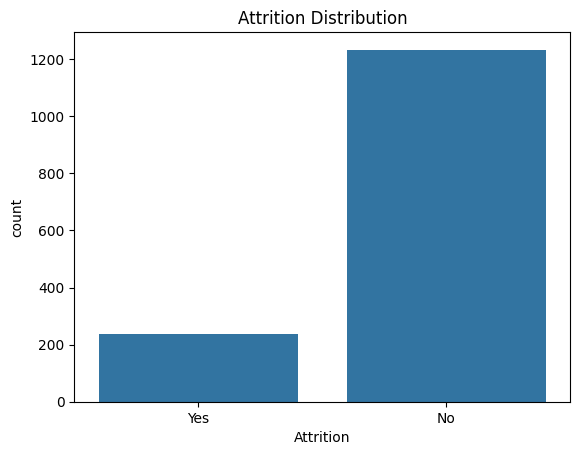

In [7]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

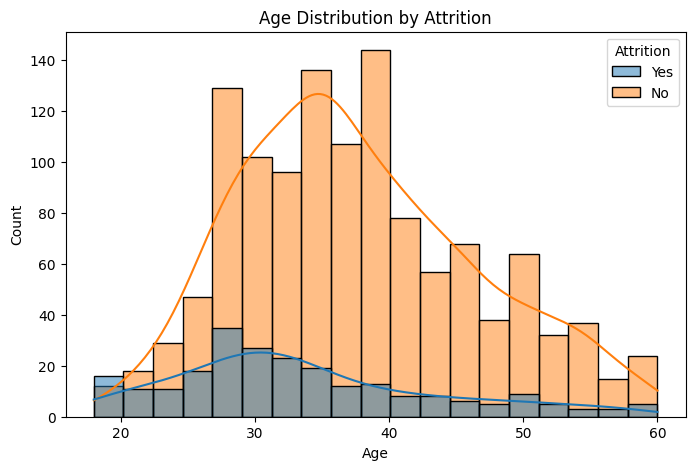

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.title('Age Distribution by Attrition')
plt.show()

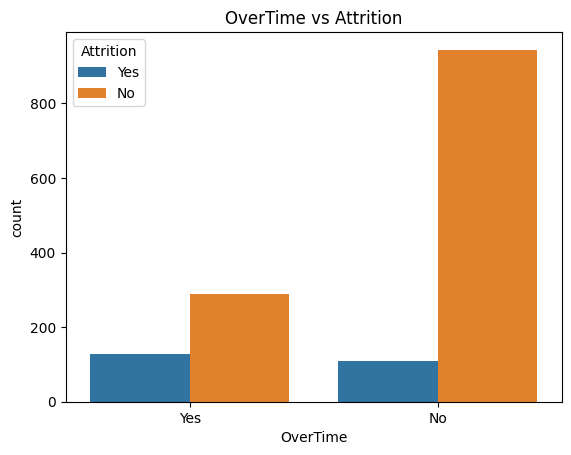

In [9]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

### Insight

Employees who work overtime show a noticeably higher attrition rate.
This suggests that workload and extended working hours may significantly influence employee turnover.

In [10]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [11]:
df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [12]:
df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [13]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [14]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### Class Imbalance Observation

The dataset is imbalanced.  
Most employees did not leave the company (0 = 1233),  
while a smaller portion left (1 = 237).

This imbalance may affect model performance, so evaluation metrics beyond accuracy (e.g., precision, recall, F1-score) will be considered.

In [15]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
X.shape

(1470, 47)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [22]:
y_pred = model.predict(X_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7414965986394558
              precision    recall  f1-score   support

           0       0.91      0.77      0.83       247
           1       0.33      0.62      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.69      0.63       294
weighted avg       0.82      0.74      0.77       294



Model Improvement

After applying class_weight='balanced', the recall for the attrition class increased significantly from 0.34 to 0.62.

Although overall accuracy decreased, the model is now better at identifying employees who are likely to leave, which is more important for business decision-making.

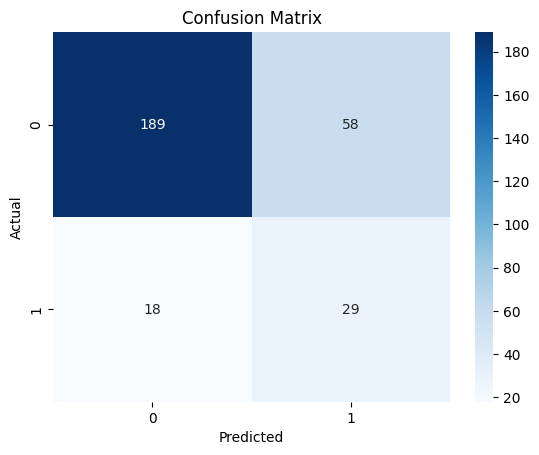

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients.sort_values().tail(10)

MaritalStatus_Single                0.444645
NumCompaniesWorked                  0.466670
Department_Sales                    0.491364
YearsSinceLastPromotion             0.497004
BusinessTravel_Travel_Rarely        0.512765
JobRole_Sales Representative        0.537179
JobLevel                            0.665793
BusinessTravel_Travel_Frequently    0.722085
OverTime_Yes                        0.773091
JobRole_Laboratory Technician       0.812771
dtype: float64

In [26]:
# Get probabilities instead of direct predictions
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Change threshold from 0.5 to 0.4
y_pred_new = (y_proba >= 0.4).astype(int)

# Evaluate
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.73      0.82       247
           1       0.36      0.79      0.49        47

    accuracy                           0.74       294
   macro avg       0.65      0.76      0.66       294
weighted avg       0.85      0.74      0.77       294



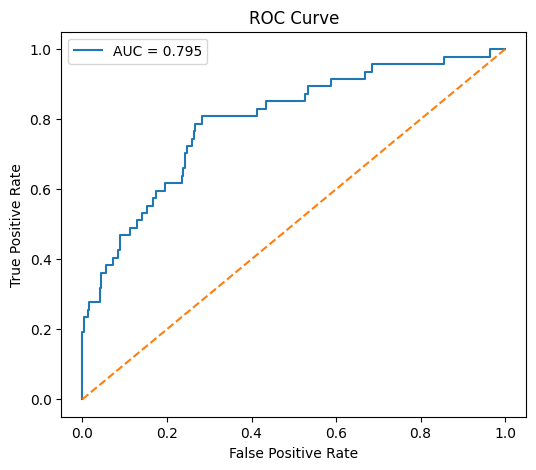

AUC Score: 0.7954173486088381


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)